# Лекция 1. Полный перенос Maple в Jupyter — Task 02

Полная лекция по `lection(1).pdf` (страницы 1–15). Основа — notebook первого задания; дополнена только копия в `task02`.

Запуск: **Restart Kernel → Run All Cells**. Требуются Python 3, SymPy, NumPy, Matplotlib и Jupyter. Оба notebook независимы друг от друга.

`prev` заменяет Maple `%`: команда использует предыдущее значение, затем записывает новый результат. Точные числа задаются через SymPy; десятичные — из строк с точностью `Digits`. Последовательности Maple представлены Python `tuple`, списки — `list`, множества — `set`. Порядок печати элементов множества может отличаться.

Каждой команде `plot` соответствуют две соседние кодовые ячейки: сначала `sp.plot`, затем `plt.plot`. Они используют одно и то же выражение. Все импорты находятся в отдельных ячейках ниже.

In [8]:
import sympy as sp

In [9]:
import numpy as np

In [10]:
import matplotlib.pyplot as plt

In [11]:
from IPython.display import display

## Начальное состояние

`restart:` в Maple очищает состояние ядра. В Jupyter ему соответствует перезапуск ядра. Следующая ячейка задаёт все используемые обозначения заново. `Digits` в SymPy не является глобальной настройкой: явно передаём её в `Float` и `N`.

In [12]:
x, y, t = sp.symbols('x y t')
f = sp.Function('f')
g = sp.Function('g')
Digits = 10
prev = None
sp.init_printing(use_latex='mathjax')

## Числа: арифметические операции

**Maple:** `1+2;`

In [13]:
prev = sp.Integer(1)+2
display(prev)

3

**Maple:** `1+3/2;`

In [14]:
prev = 1+sp.Rational(3,2)
display(prev)

5/2

**Maple:** `2*(3+1/3)/(5/3-4/5);`

In [15]:
prev = 2*(3+sp.Rational(1,3))/(sp.Rational(5,3)-sp.Rational(4,5))
display(prev)

100
───
13 

**Maple:** `2.8754/2;`

In [16]:
prev = sp.Float('2.8754', Digits)/2
display(prev)

1.437700000

В исходной строке `1+2; 75-3; 5*3; 120/2;` четыре команды; каждой соответствует отдельная ячейка.

**Maple:** `1+2;`

In [17]:
prev = sp.Integer(1)+2
display(prev)

3

**Maple:** `75-3;`

In [18]:
prev = sp.Integer(75)-3
display(prev)

72

**Maple:** `5*3;`

In [19]:
prev = sp.Integer(5)*3
display(prev)

15

**Maple:** `120/2;`

In [20]:
prev = sp.Rational(120,2)
display(prev)

60

**Maple:** `sqrt(2);`

In [21]:
prev = sp.sqrt(2)
display(prev)

√2

**Maple:** `sqrt(2.);`

In [22]:
prev = sp.sqrt(sp.Float('2.', Digits))
display(prev)

1.414213562

**Maple:** `sqrt(-2);`

In [23]:
prev = sp.sqrt(-2)
display(prev)

√2⋅ⅈ

**Maple:** `(-2)^(1/2);`

In [24]:
prev = sp.Integer(-2)**sp.Rational(1,2)
display(prev)

√2⋅ⅈ

## Комплексные числа

**Maple:** `(2+5*I)+(1-I);`

In [25]:
prev = (2+5*sp.I)+(1-sp.I)
display(prev)

3 + 4⋅ⅈ

**Maple:** `(1+I)/(3-2*I);`

In [26]:
prev = sp.expand_complex((1+sp.I)/(3-2*sp.I))
display(prev)

1    5⋅ⅈ
── + ───
13   13 

## Предопределённые константы

Maple `gamma` — постоянная Эйлера, в SymPy это `EulerGamma`, а не гамма-функция.

**Maple:** `Pi;`

In [27]:
prev = sp.pi
display(prev)

π

**Maple:** `exp(1);`

In [28]:
prev = sp.exp(1)
display(prev)

ℯ

**Maple:** `gamma;`

In [29]:
prev = sp.EulerGamma
display(prev)

γ

## Простейшие функции

**Maple:** `100!;`

Факториал.

In [30]:
prev = sp.factorial(100)
display(prev)

933262154439441526816992388562667004907159682643816214685929638952175999932299 ↪

↪ 1560894146397615651828625369792082722375825118521091686400000000000000000000 ↪

↪ 0000

**Maple:** `length(%);`

Для полученного положительного целого длина — количество десятичных цифр.

In [31]:
prev = len(str(prev))
display(prev)

158

`ifactor` заменён на `factorint(..., visual=True)`: результат отображается произведением простых множителей, а не словарём.

**Maple:** `ifactor(324823167617);`

In [32]:
prev = sp.factorint(324823167617, visual=True)
display(prev)

  1    1         1
13 ⋅367 ⋅68082827 

**Maple:** `ifactor(3185);`

In [33]:
prev = sp.factorint(3185, visual=True)
display(prev)

  1  1  2
13 ⋅5 ⋅7 

**Maple:** `ifactor(324823167617/3185);`

In [34]:
prev = sp.factorrat(sp.Rational(324823167617,3185), visual=True)
display(prev)

   1         1
367 ⋅68082827 
──────────────
        2     
     5⋅7      

**Maple:** `isprime(18002676583);`

Проверка простоты.

In [35]:
prev = sp.isprime(18002676583)
display(prev)

True

**Maple:** `ifactor(18002676583);`

In [36]:
prev = sp.factorint(18002676583, visual=True)
display(prev)

           1
18002676583 

**Maple:** `Pi;`

In [37]:
prev = sp.pi
display(prev)

π

**Maple:** `evalf(Pi);`

Переход к числу с плавающей точкой.

In [38]:
prev = sp.N(sp.pi, Digits)
display(prev)

3.141592654

**Maple:** `evalf(Pi,100);`

In [39]:
prev = sp.N(sp.pi, 100)
display(prev)

3.1415926535897932384626433832795028841971693993751058209749445923078164062862 ↪

↪ 08998628034825342117068

**Maple:** `evalf[20](Pi);`

In [40]:
prev = sp.N(sp.pi, 20)
display(prev)

3.1415926535897932385

**Maple:** `evalf(Pi,1);`

In [41]:
prev = sp.N(sp.pi, 1)
display(prev)

3.

**Maple:** `evalf(Pi,2);`

In [42]:
prev = sp.N(sp.pi, 2)
display(prev)

3.1

**Maple:** `evalf(Pi,3);`

In [43]:
prev = sp.N(sp.pi, 3)
display(prev)

3.14

**Maple:** `evalf(Pi,4);`

In [44]:
prev = sp.N(sp.pi, 4)
display(prev)

3.142

**Maple:** `evalf(Pi,5);`

In [45]:
prev = sp.N(sp.pi, 5)
display(prev)

3.1416

**Maple:** `gamma;`

In [46]:
prev = sp.EulerGamma
display(prev)

γ

**Maple:** `evalf(gamma);`

In [47]:
prev = sp.N(sp.EulerGamma, Digits)
display(prev)

0.5772156649

**Maple:** `34/51;`

In [48]:
prev = sp.Rational(34,51)
display(prev)

2/3

**Maple:** `evalf(%);`

In [49]:
prev = sp.N(prev, Digits)
display(prev)

0.6666666667

**Maple:** `3/2*5;`

In [50]:
prev = sp.Rational(3,2)*5
display(prev)

15/2

**Maple:** `1.5*5;`

In [51]:
prev = sp.Float('1.5', Digits)*5
display(prev)

7.500000000

**Maple:** `sin(Pi);`

In [52]:
prev = sp.sin(sp.pi)
display(prev)

0

**Maple:** `exp(1);`

In [53]:
prev = sp.exp(1)
display(prev)

ℯ

**Maple:** `ln(exp(5));`

In [54]:
prev = sp.log(sp.exp(5))
display(prev)

5

**Maple:** `log[7.5](7.5^2);`

In [55]:
prev = sp.N(sp.log(sp.Float('7.5', Digits)**2, sp.Float('7.5', Digits)), Digits)
display(prev)

2.000000000

**Maple:** `Digits;`

In [56]:
prev = Digits
display(prev)

10

## Параметры ядра: kernelopts

Эти команды описывают конкретное ядро Maple; результаты из лекции не являются константами Python. Согласно заданию они сохранены как пояснения без искусственной эмуляции.

| Maple | Смысл и соответствие |
|---|---|
| `kernelopts(maxdigits)` | Предел `Digits` ядра Maple. SymPy поддерживает произвольную точность в пределах доступных ресурсов. |
| `kernelopts(username)` | Имя пользователя ОС; в Python доступно через `getpass.getuser()`. |
| `kernelopts(homedir)` | Домашний каталог; аналог — `pathlib.Path.home()`. |
| `kernelopts(numcpus)` | Число процессоров; аналог — `os.cpu_count()`. |
| `kernelopts(wordsize)` | Разрядность Maple; это не ограничение длины целых Python. |
| `kernelopts(cpulimit)` | Лимит процессорного времени Maple; единого переносимого аналога нет. |

Комментарий о Shift+Enter: в Jupyter это выполнение ячейки и переход к следующей; обычный Enter вставляет новую строку кода.

## Строки и настройка точности

Прямой слеш записывается как `/`, обратный в строковом литерале — как `\\`.

**Maple:** `"C:/Users\\";`

In [57]:
prev = 'C:/Users\\'
display(prev)

'C:/Users\\'

**Maple:** `sin(0.2);`

In [58]:
prev = sp.sin(sp.Float('0.2', Digits))
display(prev)

0.1986693308

**Maple:** `Digits:=20;`

In [59]:
Digits = 20
prev = Digits
display(prev)

20

**Maple:** `sin(0.2);`

In [60]:
prev = sp.sin(sp.Float('0.2', Digits))
display(prev)

0.19866933079506121546

**Maple:** `Digits:=10;`

In [61]:
Digits = 10
prev = Digits
display(prev)

10

**Maple:** `123456+sin(1.2);`

In [62]:
prev = sp.N(123456+sp.sin(sp.Float('1.2', Digits)), Digits)
display(prev)

123456.9320

Комментарии интерфейса Maple: F4 объединяет блоки, F3 разрывает блок у курсора. В Jupyter соответствующие действия доступны через команды объединения и разделения ячеек; сочетания клавиш зависят от интерфейса.

## Системы счисления

Результаты перевода в двоичную и шестнадцатеричную системы представлены строками цифр. Обратный перевод действительно использует `prev`.

**Maple:** `convert(247,binary);`

In [63]:
prev = format(247, 'b')
display(prev)

'11110111'

**Maple:** `convert(%,decimal,binary);`

In [64]:
prev = sp.Integer(int(prev, 2))
display(prev)

247

**Maple:** `convert(1023,hex);`

In [65]:
prev = format(1023, 'X')
display(prev)

'3FF'

**Maple:** `convert(23,decimal,17);`

In [66]:
prev = sp.Integer(int('23', 17))
display(prev)

37

**Maple:** `2*17+3 = 3*10+7;`

In [67]:
prev = sp.Eq(2*17+3, 3*10+7, evaluate=False)
display(prev)

37 = 37

## Символьные выражения

Простейшие выражения и функции над ними; раскрытие скобок и разложение на множители.

**Maple:** `(1+x)+(3-2*x);`

In [68]:
prev = (1+x)+(3-2*x)
display(prev)

4 - x

**Maple:** `(1-x)^2;`

In [69]:
prev = (1-x)**2
display(prev)

       2
(1 - x) 

**Maple:** `expand((1-x)^2);`

In [70]:
prev = sp.expand((1-x)**2)
display(prev)

 2          
x  - 2⋅x + 1

**Maple:** `factor(%);`

In [71]:
prev = sp.factor(prev)
display(prev)

       2
(x - 1) 

## Дифференцирование

`diff` вычисляет производную, `Derivative(..., evaluate=False)` хранит её в неактивном виде. `doit()` соответствует `value`. Равенства создаются с `evaluate=False`, чтобы сохранить обе стороны вместо логического `True`.

**Maple:** `diff(cos(x),x);`

In [72]:
prev = sp.diff(sp.cos(x), x)
display(prev)

-sin(x)

**Maple:** `Diff(cos(x),x);`

In [73]:
prev = sp.Derivative(sp.cos(x), x, evaluate=False)
display(prev)

d         
──(cos(x))
dx        

**Maple:** `Diff(cos(x),x)=diff(cos(x),x);`

In [74]:
prev = sp.Eq(sp.Derivative(sp.cos(x), x, evaluate=False), sp.diff(sp.cos(x), x), evaluate=False)
display(prev)

d                   
──(cos(x)) = -sin(x)
dx                  

**Maple:** `value(Diff(cos(x),x));`

In [75]:
prev = sp.Derivative(sp.cos(x), x, evaluate=False).doit()
display(prev)

-sin(x)

**Maple:** `Diff(cos(x*y),x)=diff(cos(x*y),x);`

In [76]:
prev = sp.Eq(sp.Derivative(sp.cos(x*y), x, evaluate=False), sp.diff(sp.cos(x*y), x), evaluate=False)
display(prev)

∂                         
──(cos(x⋅y)) = -y⋅sin(x⋅y)
∂x                        

**Maple:** `value(%);`

In [77]:
prev = sp.Eq(prev.lhs.doit(), prev.rhs.doit(), evaluate=False)
display(prev)

-y⋅sin(x⋅y) = -y⋅sin(x⋅y)

**Maple:** `D[2](f)(x,y)=convert(D[2](f)(x,y),Diff);`

Производная по второму аргументу. SymPy записывает операторную и обычную частную производную одним объектом `Derivative`, поэтому обе стороны выглядят одинаково.

In [78]:
prev = sp.Eq(sp.diff(f(x,y), y), sp.Derivative(f(x,y), y, evaluate=False), evaluate=False)
display(prev)

∂             ∂          
──(f(x, y)) = ──(f(x, y))
∂y            ∂y         

**Maple:** `diff(sin(x),x,x,x);`

In [79]:
prev = sp.diff(sp.sin(x), x, x, x)
display(prev)

-cos(x)

Для Maple `D` определим оператор, возвращающий функцию `Lambda`. Это позволяет буквально повторить вложенное применение оператора и его трёхкратную композицию.

In [80]:
def D(function):
    return sp.Lambda(t, sp.diff(function(t), t))

def iterate_operator(operator, count):
    def repeated(function):
        for _ in range(count):
            function = operator(function)
        return function
    return repeated

**Maple:** `D(D(D(sin)));`

In [81]:
prev = D(D(D(sp.sin)))
display(prev)

t ↦ -cos(t)

**Maple:** `D(D(D(sin)))(x);`

In [82]:
prev = D(D(D(sp.sin)))(x)
display(prev)

-cos(x)

**Maple:** `(D@@3)(sin)(x);`

In [83]:
prev = iterate_operator(D, 3)(sp.sin)(x)
display(prev)

-cos(x)

**Maple:** `diff(f(g(x)),x);`

In [84]:
prev = sp.diff(f(g(x)), x)
display(prev)

  d            d       
─────(f(g(x)))⋅──(g(x))
dg(x)          dx      

**Maple:** `convert(%,diff);`

SymPy уже выразил результат через `Derivative` и `Subs`. Преобразование не меняет запись, но применяется именно к предыдущему результату.

In [85]:
prev = prev.doit()
display(prev)

  d            d       
─────(f(g(x)))⋅──(g(x))
dg(x)          dx      

**Maple:** `D(f@g)(x);`

Суперпозиция `f@g` задаётся как `Lambda(t, f(g(t)))`.

In [86]:
prev = D(sp.Lambda(t, f(g(t))))(x)
display(prev)

  d            d       
─────(f(g(x)))⋅──(g(x))
dg(x)          dx      

## Ряды Тейлора и Лорана

Параметр порядка `series` в Maple и SymPy может давать разную запись остатка. Ниже выбран порядок, воспроизводящий члены и остатки, показанные в PDF: $O(x^{11})$, $O((x-1)^9)$ и $O(x^{-12})$.

**Maple:** `series(sin(x),x=0,10);`

Ряд Тейлора у нуля.

In [87]:
prev = sp.series(sp.sin(x), x, 0, 11)
display(prev)

     3    5      7       9           
    x    x      x       x       ⎛ 11⎞
x - ── + ─── - ──── + ────── + O⎝x  ⎠
    6    120   5040   362880         

**Maple:** `series(1/(1-x^2),x=1,10);`

Ряд Лорана у полюса $x=1$.

In [88]:
prev = sp.series(1/(1-x**2), x, 1, 9)
display(prev)

                         2          3          4          5          6         ↪
      1       3   (x - 1)    (x - 1)    (x - 1)    (x - 1)    (x - 1)    (x -  ↪
- ───────── + ─ + ──────── - ──────── + ──────── - ──────── + ──────── - ───── ↪
  2⋅(x - 1)   8      16         32         64        128        256        512 ↪

↪   7          8                         
↪ 1)    (x - 1)    x    ⎛       9       ⎞
↪ ─── + ──────── - ─ + O⎝(x - 1) ; x → 1⎠
↪         1024     8                     

**Maple:** `series(1/(1+x^3),x=infinity,10);`

Асимптотическое разложение при $x\to\infty$.

In [89]:
prev = sp.series(1/(1+x**3), x, sp.oo, 12)
display(prev)

1    1    1     ⎛ 1        ⎞
── - ── + ── + O⎜───; x → ∞⎟
 9    6    3    ⎜ 12       ⎟
x    x    x     ⎝x         ⎠

**Maple:** `convert(%,polynom);`

Удаление остаточного члена из предыдущего ряда. Здесь получается многочлен по $1/x$, а не по $x$.

In [90]:
prev = prev.removeO()
display(prev)

1    1    1 
── - ── + ──
 3    6    9
x    x    x 

## График ошибки асимптотического приближения

**Maple:** `plot(abs(1/(1+x^3)-%),x=1..10,thickness=3,view=[0..10,0..1]);`

Две реализации одной зависимости: SymPy, затем Matplotlib. Диапазон вычисления и видимое окно сохранены.

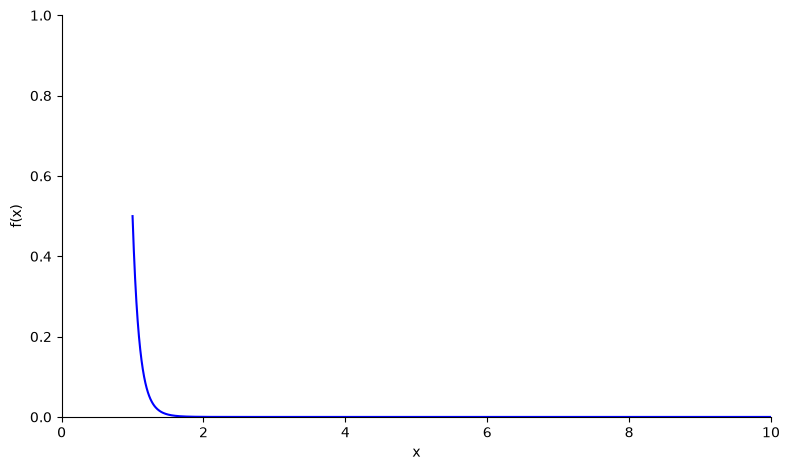

In [91]:
approximation = prev
plot_expression = sp.Abs(1/(1+x**3)-approximation)
prev = sp.plot(plot_expression, (x, 1, 10), line_color='blue', rendering_kw={"linewidth": 3}, xlabel='x', ylabel="f(x)", axis_center=(0, 0), size=(8, 4.8), xlim=(0, 10), ylim=(0, 1), show=False)
prev[0].rendering_kw = {"linewidth": 3}
prev.show()

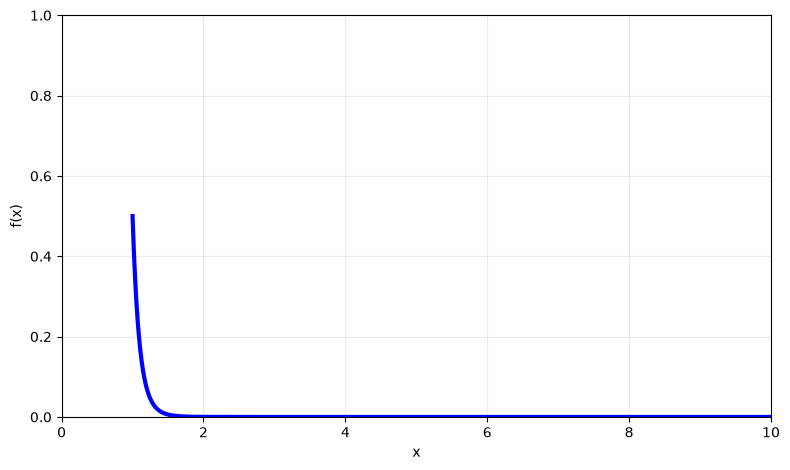

In [92]:
x_values = np.linspace(1, 10, 1500)
plot_function = sp.lambdify(x, plot_expression, "numpy")
fig = plt.figure(figsize=(8, 4.8))
plt.plot(x_values, plot_function(x_values), color='blue', linewidth=3)
plt.xlim(0, 10)
plt.ylim(0, 1)
plt.xlabel('x')
plt.ylabel("f(x)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
prev = fig
plt.show()

## Переменные, выражения, равенства, функции

Дополнительные обозначения для оставшихся разделов.

In [93]:
a, b, c, d, e, z, w, tau = sp.symbols('a b c d e z w tau')
alpha, Beta, lambda_symbol, Theta = sp.symbols('alpha Beta lambda Theta')
F = sp.Function('F')

**Maple:** `var:=x;`

Переменной `var` присвоено символьное значение `x`.

In [94]:
var = x
prev = var
display(prev)

x

**Maple:** `term:=x*y;`

Произведение хранится в переменной.

In [95]:
term = x*y
prev = term
display(prev)

x⋅y

**Maple:** `eqs:=x=y+2;`

Равенство задаётся объектом `Eq`.

In [96]:
eqs = sp.Eq(x, y+2)
prev = eqs
display(prev)

x = y + 2

**Maple:** `f:=x->2*x^2-3*x+4;`

Определение функции одного аргумента.

In [97]:
f = sp.Lambda(x, 2*x**2-3*x+4)
prev = f
display(prev)

       2          
x ↦ 2⋅x  - 3⋅x + 4

**Maple:** `f(1);`

In [98]:
prev = f(1)
display(prev)

3

**Maple:** `f(a+1);`

In [99]:
prev = f(a+1)
display(prev)

                2    
-3⋅a + 2⋅(a + 1)  + 1

**Maple:** `sin(Pi/3);`

In [100]:
prev = sp.sin(sp.pi/3)
display(prev)

√3
──
2 

**Maple:** `Pi:=3.14;` и `set:={1,2,3};`

В Maple обе строки демонстрируют ошибку присваивания защищённым именам. В Python такая защита имён отсутствует; намеренно не переопределяем `sp.pi` и встроенный `set`. Ошибочные присваивания не выполняются, чтобы Run All завершался без ошибок.

Комментарий исходника: `protect` устанавливает защиту, `unprotect` снимает её; они будут изучаться позже. Это механизм Maple, который здесь не эмулируется.

**Maple:** `MySet:={1,2,3};`

Множество из трёх чисел.

In [101]:
MySet = {1, 2, 3}
prev = MySet
display(prev)

{1, 2, 3}

## Графики

**Maple:** `f:=tau->(sin(tau)-1)^2-1;`

In [102]:
f = sp.Lambda(tau, (sp.sin(tau)-1)**2-1)
prev = f
display(prev)

                2    
τ ↦ (sin(τ) - 1)  - 1

**Maple:** `plot(f(x),x=-5...5);`

Две реализации одной зависимости: SymPy, затем Matplotlib. Диапазон вычисления и видимое окно сохранены.

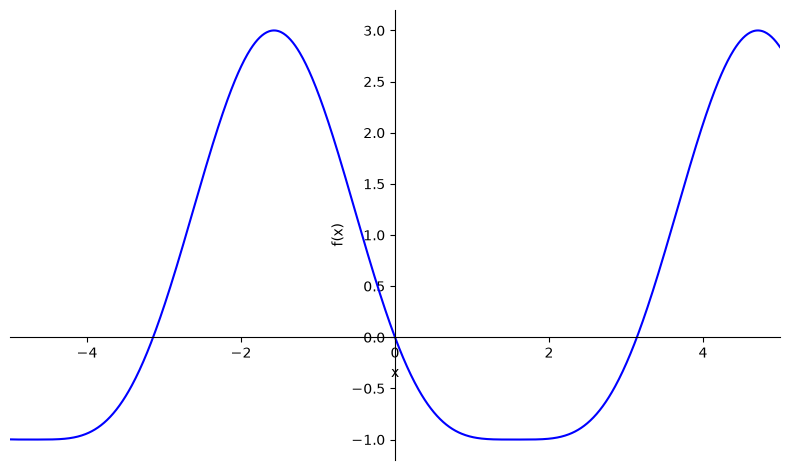

In [103]:
plot_expression = f(x)
prev = sp.plot(plot_expression, (x, -5, 5), line_color='blue', rendering_kw={"linewidth": 2}, xlabel='x', ylabel="f(x)", axis_center=(0, 0), size=(8, 4.8), xlim=(-5, 5), show=False)
prev[0].rendering_kw = {"linewidth": 2}
prev.show()

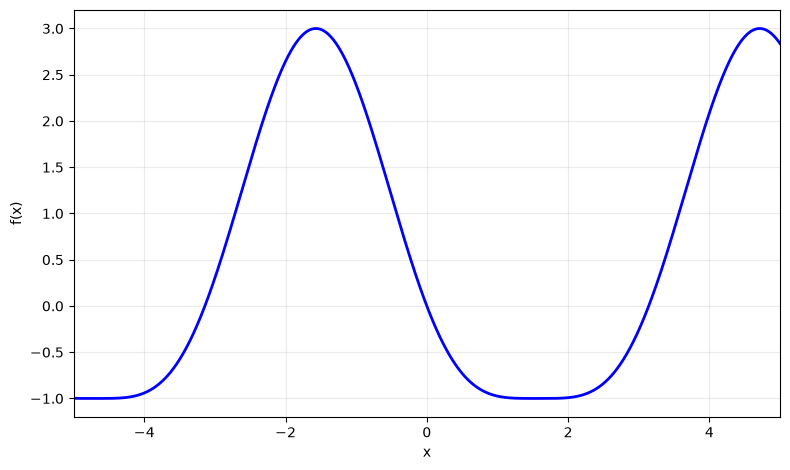

In [104]:
x_values = np.linspace(-5, 5, 1500)
plot_function = sp.lambdify(x, plot_expression, "numpy")
fig = plt.figure(figsize=(8, 4.8))
plt.plot(x_values, plot_function(x_values), color='blue', linewidth=2)
plt.xlim(-5, 5)
plt.xlabel('x')
plt.ylabel("f(x)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
prev = fig
plt.show()

**Maple:** `plot((sin(tau)-1)^2-1,tau=-5...5,color=blue,thickness=4,view=[-3..3,-1..1]);`

Две реализации одной зависимости: SymPy, затем Matplotlib. Диапазон вычисления и видимое окно сохранены.

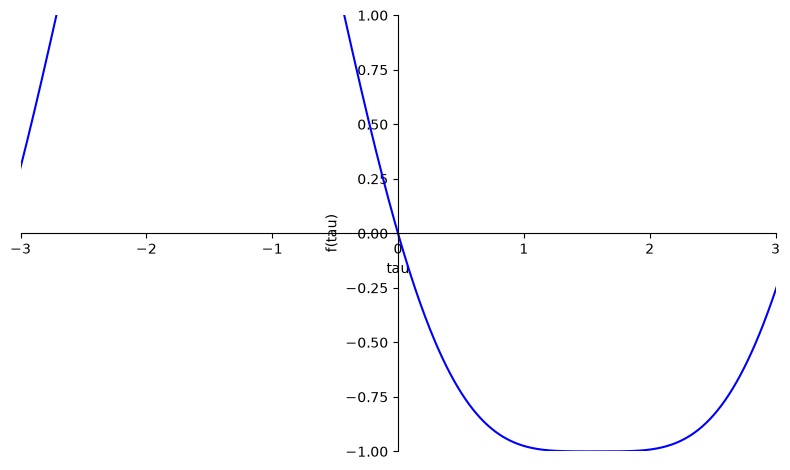

In [105]:
plot_expression = (sp.sin(tau)-1)**2-1
prev = sp.plot(plot_expression, (tau, -5, 5), line_color='blue', rendering_kw={"linewidth": 4}, xlabel='tau', ylabel="f(tau)", axis_center=(0, 0), size=(8, 4.8), xlim=(-3, 3), ylim=(-1, 1), show=False)
prev[0].rendering_kw = {"linewidth": 4}
prev.show()

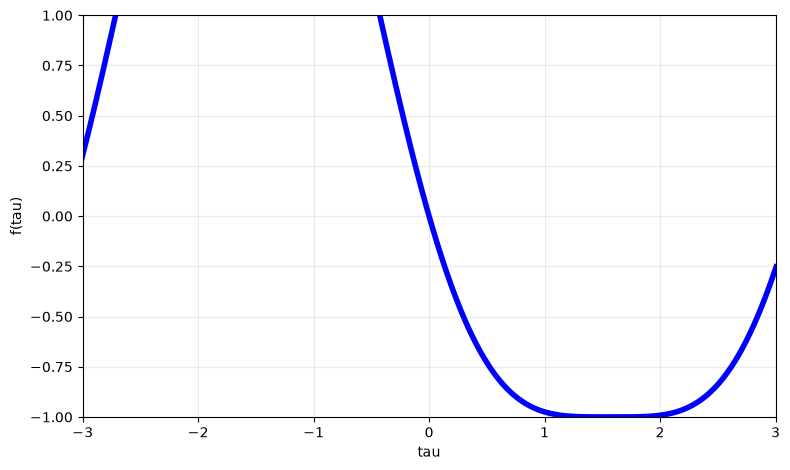

In [106]:
x_values = np.linspace(-5, 5, 1500)
plot_function = sp.lambdify(tau, plot_expression, "numpy")
fig = plt.figure(figsize=(8, 4.8))
plt.plot(x_values, plot_function(x_values), color='blue', linewidth=4)
plt.xlim(-3, 3)
plt.ylim(-1, 1)
plt.xlabel('tau')
plt.ylabel("f(tau)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
prev = fig
plt.show()

## Последовательности, списки, множества

Последовательность Maple представляется кортежем Python (`tuple`). В отличие от Maple Python не раскрывает кортеж автоматически внутри списка или множества: применяем `list(...)`, `set(...)` или распаковку `*`.

**Maple:** `1,2,3,4;`

Последовательность чисел.

In [107]:
prev = (1, 2, 3, 4)
display(prev)

(1, 2, 3, 4)

**Maple:** `x,y,z,w;`

Последовательность символов.

In [108]:
prev = (x, y, z, w)
display(prev)

(x, y, z, w)

**Maple:** `a||b;`

Конкатенация имён создаёт новый символьный идентификатор.

In [109]:
prev = sp.Symbol(str(a)+str(b))
display(prev)

ab

**Maple:** `S:=1,2,3,4;`

In [110]:
S = (1, 2, 3, 4)
prev = S
display(prev)

(1, 2, 3, 4)

**Maple:** `a||S;`

In [111]:
prev = tuple(sp.Symbol(str(a)+str(item)) for item in S)
display(prev)

(a₁, a₂, a₃, a₄)

**Maple:** `data_list:=[1,2,3,4,5];`

Список чисел.

In [112]:
data_list = [1, 2, 3, 4, 5]
prev = data_list
display(prev)

[1, 2, 3, 4, 5]

**Maple:** `polynominals:=[x^2+3,x^2+3*x-1,2*x];`

Список выражений; имя сохранено как в оригинале.

In [113]:
polynominals = [x**2+3, x**2+3*x-1, 2*x]
prev = polynominals
display(prev)

⎡ 2       2               ⎤
⎣x  + 3, x  + 3⋅x - 1, 2⋅x⎦

**Maple:** `преподаватели:=["Orlov","Smirnov","Kiselev","Samsonov","Камзолкин"];`

Список строк.

In [114]:
преподаватели = ["Orlov", "Smirnov", "Kiselev", "Samsonov", "Камзолкин"]
prev = преподаватели
display(prev)

['Orlov', 'Smirnov', 'Kiselev', 'Samsonov', 'Камзолкин']

**Maple:** `[a,b,c],[b,c,a],[a,a,b,c,a];`

Последовательность списков.

In [115]:
prev = ([a,b,c], [b,c,a], [a,a,b,c,a])
display(prev)

([a, b, c], [b, c, a], [a, a, b, c, a])

**Maple:** `letters:=[alpha,Beta,gamma,lambda,Theta];`

`gamma` по-прежнему постоянная Эйлера. `lambda` — ключевое слово Python, поэтому символ хранится под именем `lambda_symbol`.

In [116]:
letters = [alpha, Beta, sp.EulerGamma, lambda_symbol, Theta]
prev = letters
display(prev)

[α, Β, γ, λ, Θ]

**Maple:** `letters[2];`

Индексация Python начинается с нуля; второй элемент имеет индекс 1.

In [117]:
prev = letters[1]
display(prev)

Β

**Maple:** `letters[-1];`

Последний элемент.

In [118]:
prev = letters[-1]
display(prev)

Θ

**Maple:** `letters[2..3];`

В Python правая граница среза не включается.

In [119]:
prev = letters[1:3]
display(prev)

[Β, γ]

**Maple:** `letters[-3..-1];`

Три последних элемента.

In [120]:
prev = letters[-3:]
display(prev)

[γ, λ, Θ]

**Maple:** `nops(letters);`

Количество элементов списка.

In [121]:
prev = len(letters)
display(prev)

5

**Maple:** `op(letters);`

Элементы списка как последовательность.

In [122]:
prev = tuple(letters)
display(prev)

(α, Β, γ, λ, Θ)

**Maple:** `letters[];`

Альтернативная запись той же последовательности.

In [123]:
prev = tuple(letters)
display(prev)

(α, Β, γ, λ, Θ)

**Maple:** `data_set:={0,-1,0,10,2};`

Повторяющийся ноль удаляется: остаются четыре элемента.

In [124]:
data_set = {0, -1, 0, 10, 2}
prev = data_set
display(prev)

{-1, 0, 2, 10}

**Maple:** `unknowns:={x,y,z};`

In [125]:
unknowns = {x,y,z}
prev = unknowns
display(prev)

{x, y, z}

**Maple:** `{a,b,c},{c,b,a},{a,a,b,c,a};`

Порядок и повторы не меняют множество.

In [126]:
prev = ({a,b,c}, {c,b,a}, {a,a,b,c,a})
display(prev)

({a, b, c}, {a, b, c}, {a, b, c})

**Maple:** `{1,2,2.0};`

Обычный Python объединяет `2` и `2.0`. Символьные `Integer` и `Float` различаются структурно, что сохраняет три элемента, как в Maple.

In [127]:
prev = {sp.Integer(1), sp.Integer(2), sp.Float('2.0', Digits)}
display(prev)

{1, 2, 2.0}

**Maple:** `{a,b,c} union {c,d,e};`

In [128]:
prev = {a,b,c} | {c,d,e}
display(prev)

{a, b, c, d, e}

**Maple:** `{1,2,3} intersect {0,1,y,a};`

In [129]:
prev = {1,2,3} & {0,1,y,a}
display(prev)

{1}

**Maple:** `nops(%);`

Количество элементов непосредственно предыдущего результата.

In [130]:
prev = len(prev)
display(prev)

1

**Maple:** `{1,2,3} minus {0,1,y,a};`

In [131]:
prev = {1,2,3} - {0,1,y,a}
display(prev)

{2, 3}

**Maple:** `op({1,2,3,a,b});`

Множество не упорядочено; сортировка задаёт устойчивый порядок вывода кортежа.

In [132]:
prev = tuple(sorted({1,2,3,a,b}, key=sp.default_sort_key))
display(prev)

(1, 2, 3, a, b)

**Maple:** `numbers:={0,Pi/3,Pi/2,Pi};`

In [133]:
numbers = {sp.Integer(0), sp.pi/3, sp.pi/2, sp.pi}
prev = numbers
display(prev)

⎧   π  π   ⎫
⎨0, ─, ─, π⎬
⎩   3  2   ⎭

**Maple:** `map(F,numbers);`

Применение функции к каждому элементу множества.

In [134]:
prev = {F(item) for item in numbers}
display(prev)

⎧       ⎛π⎞   ⎛π⎞      ⎫
⎨F(0), F⎜─⎟, F⎜─⎟, F(π)⎬
⎩       ⎝3⎠   ⎝2⎠      ⎭

**Maple:** `map(x->x^2,numbers);`

In [135]:
prev = {item**2 for item in numbers}
display(prev)

⎧    2   2    ⎫
⎪   π   π    2⎪
⎨0, ──, ──, π ⎬
⎪   9   4     ⎪
⎩             ⎭

**Maple:** `map(sin,numbers);`

Синусы 0 и π совпадают; остаётся три элемента.

In [136]:
prev = {sp.sin(item) for item in numbers}
display(prev)

⎧      √3⎫
⎨0, 1, ──⎬
⎩      2 ⎭

**Maple:** `преподаватели;`

In [137]:
prev = преподаватели
display(prev)

['Orlov', 'Smirnov', 'Kiselev', 'Samsonov', 'Камзолкин']

**Maple:** `member("Orlov",преподаватели);`

In [138]:
prev = "Orlov" in преподаватели
display(prev)

True

**Maple:** `member("Оrlov",преподаватели);`

Первая буква здесь — русская «О», поэтому результат False.

In [139]:
prev = "Оrlov" in преподаватели
display(prev)

False

**Maple:** `member("Kozlov",преподаватели);`

In [140]:
prev = "Kozlov" in преподаватели
display(prev)

False

**Maple:** `empty_sequence:=NULL;`

Пустая последовательность — пустой кортеж, не `None`.

In [141]:
empty_sequence = ()
prev = empty_sequence
display(prev)

()

**Maple:** `empty_set:={};`

В Python `{}` создаёт словарь; для пустого множества нужен `set()`.

In [142]:
empty_set = set()
prev = empty_set
display(prev)

set()

**Maple:** `empty_list:=[];`

In [143]:
empty_list = []
prev = empty_list
display(prev)

[]

**Maple:** `sq:=1,2,3;`

In [144]:
sq = (1,2,3)
prev = sq
display(prev)

(1, 2, 3)

**Maple:** `ls_1:=[sq];`

In [145]:
ls_1 = list(sq)
prev = ls_1
display(prev)

[1, 2, 3]

**Maple:** `ls_2:=convert('sq',list);`

Кавычки Maple задерживают вычисление имени: в PDF результат `[sq]`, а не `[1,2,3]`. Сохраняем этот результат символом `sq`.

In [146]:
ls_2 = [sp.Symbol('sq')]
prev = ls_2
display(prev)

[sq]

**Maple:** `sq_1:=op(ls_1);`

In [147]:
sq_1 = tuple(ls_1)
prev = sq_1
display(prev)

(1, 2, 3)

**Maple:** `sq_2:=ls_1[];`

In [148]:
sq_2 = tuple(ls_1)
prev = sq_2
display(prev)

(1, 2, 3)

**Maple:** `st_1:={sq};`

In [149]:
st_1 = set(sq)
prev = st_1
display(prev)

{1, 2, 3}

**Maple:** `st_2:=convert('sq',set);`

Задержанное имя даёт множество из одного символа, как в PDF.

In [150]:
st_2 = {sp.Symbol('sq')}
prev = st_2
display(prev)

{sq}

## Выполнимые выражения и математическая запись

**Maple:** `ls_3:=[op(st_1)];`

Перевод множества в список с устойчивым порядком.

In [151]:
ls_3 = [*sorted(st_1, key=sp.default_sort_key)]
prev = ls_3
display(prev)

[1, 2, 3]

**Maple:** `ls_4:=convert(st_1,list);`

In [152]:
ls_4 = list(sorted(st_1, key=sp.default_sort_key))
prev = ls_4
display(prev)

[1, 2, 3]

Следующие строки в оригинале повторяются как **текстовая запись**, переключаемая кнопкой с кленовым листком; повторно выполнять их не требуется. В Jupyter текст размещается в Markdown:

```maple
ls_3:=[op(st_1)]; ls_4:=convert(st_1,list);
```

**Maple:** `int(cos(x),x);`

Вычисление простейшего интеграла в аналитическом виде. Как в Maple, произвольная константа не добавляется автоматически.

In [153]:
prev = sp.integrate(sp.cos(x), x)
display(prev)

sin(x)

**Maple:** `∫ cos(x) dx;`

Последняя команда лекции задаёт ту же операцию в математической форме (кнопка «x» в Maple). В Jupyter `Integral` представляет интеграл, а `doit()` вычисляет его.

In [155]:
prev = sp.Integral(sp.cos(x), x).doit()
display(prev)

sin(x)